### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



### Cálculo de la facturación total

In [3]:
todas_las_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
facturacion_total = todas_las_tiendas['Precio'].sum()
print(f"La facturación total de todas las tiendas es: {facturacion_total:,.2f}")

La facturación total de todas las tiendas es: 4,403,619,200.00


# 2. Ventas por categoría

### 2. Ventas por categoría por tienda

In [7]:
# Añadir una columna de tienda a cada DataFrame individual
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Concatenar todos los DataFrames nuevamente, ahora con la columna 'Tienda'
todas_las_tiendas_con_tienda = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Calcular la cantidad de productos vendidos por categoría en cada tienda
ventas_por_categoria_tienda = todas_las_tiendas_con_tienda.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad de Productos Vendidos')

# Encontrar las categorías más populares para cada tienda
categorias_mas_populares_por_tienda = ventas_por_categoria_tienda.sort_values(by=['Tienda', 'Cantidad de Productos Vendidos'], ascending=[True, False])

print("Cantidad de productos vendidos por categoría y tienda (top 3 por tienda):\n")
for tienda_name in categorias_mas_populares_por_tienda['Tienda'].unique():
    print(f"--- {tienda_name} ---")
    display(categorias_mas_populares_por_tienda[categorias_mas_populares_por_tienda['Tienda'] == tienda_name].head(3))
    print("\n")

Cantidad de productos vendidos por categoría y tienda (top 3 por tienda):

--- Tienda 1 ---


,Tienda,Categoría del Producto,Cantidad de Productos Vendidos
7,Tienda 1,Muebles,465
3,Tienda 1,Electrónicos,448
5,Tienda 1,Juguetes,324




--- Tienda 2 ---


,Tienda,Categoría del Producto,Cantidad de Productos Vendidos
15,Tienda 2,Muebles,442
11,Tienda 2,Electrónicos,422
13,Tienda 2,Juguetes,313




--- Tienda 3 ---


,Tienda,Categoría del Producto,Cantidad de Productos Vendidos
23,Tienda 3,Muebles,499
19,Tienda 3,Electrónicos,451
21,Tienda 3,Juguetes,315




--- Tienda 4 ---


,Tienda,Categoría del Producto,Cantidad de Productos Vendidos
31,Tienda 4,Muebles,480
27,Tienda 4,Electrónicos,451
29,Tienda 4,Juguetes,338


# 3. Calificación promedio de la tienda

In [5]:
# Calcular la calificación promedio por tienda
calificacion_promedio_por_tienda = todas_las_tiendas_con_tienda.groupby('Tienda')['Calificación'].mean().reset_index()

print("Calificación promedio de clientes por tienda:\n")
display(calificacion_promedio_por_tienda.sort_values(by='Calificación', ascending=False))

Calificación promedio de clientes por tienda:



,Tienda,Calificación
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685


# 4. Productos más y menos vendidos

# 4. Productos más y menos vendidos

--- Productos más y menos vendidos por tienda ---

--- Tienda 1 ---

Top 5 Productos Más Vendidos:


,Tienda,Producto,Cantidad Vendida
1,Tienda 1,Armario,60
48,Tienda 1,TV LED UHD 4K,60
33,Tienda 1,Microondas,60
40,Tienda 1,Secadora de ropa,58
32,Tienda 1,Mesa de noche,56



Top 5 Productos Menos Vendidos:


,Tienda,Producto,Cantidad Vendida
4,Tienda 1,Auriculares con micrófono,33
13,Tienda 1,Celular ABXY,33
37,Tienda 1,Olla de presión,35
38,Tienda 1,Pandereta,36
14,Tienda 1,Ciencia de datos con Python,39


/tmp/ipykernel_569/1573215612.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_mas_vendidos, palette='viridis')


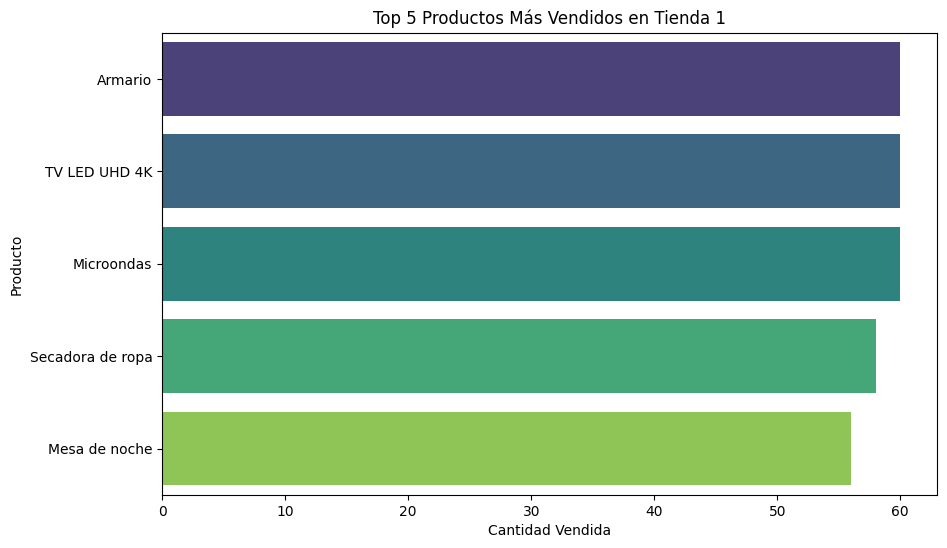

/tmp/ipykernel_569/1573215612.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_menos_vendidos, palette='magma')


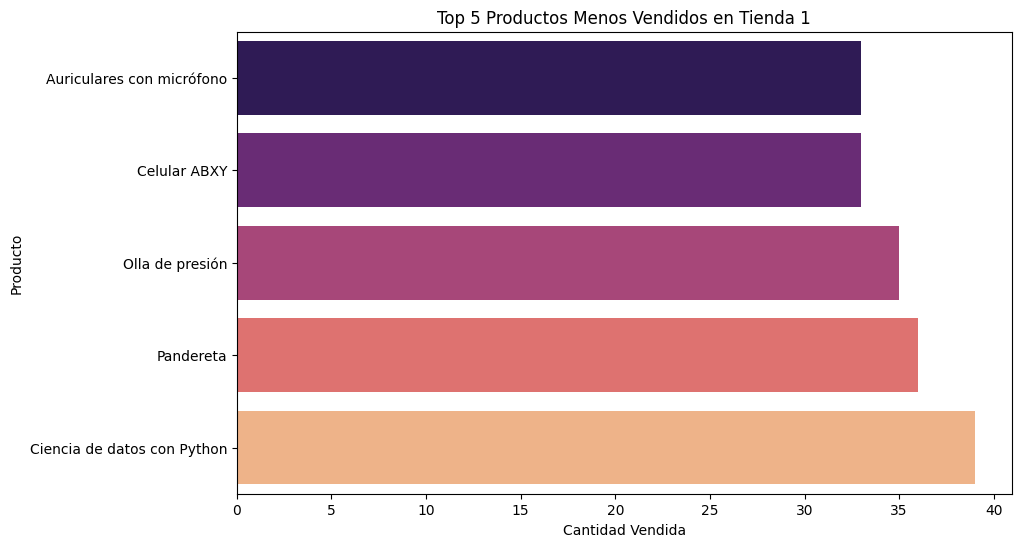



--- Tienda 2 ---

Top 5 Productos Más Vendidos:


,Tienda,Producto,Cantidad Vendida
75,Tienda 2,Iniciando en programación,65
84,Tienda 2,Microondas,62
58,Tienda 2,Batería,61
89,Tienda 2,Pandereta,58
72,Tienda 2,Guitarra acústica,58



Top 5 Productos Menos Vendidos:


,Tienda,Producto,Cantidad Vendida
77,Tienda 2,Juego de mesa,32
74,Tienda 2,Impresora,34
82,Tienda 2,Mesa de comedor,34
95,Tienda 2,Sillón,35
54,Tienda 2,Auriculares,37


/tmp/ipykernel_569/1573215612.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_mas_vendidos, palette='viridis')


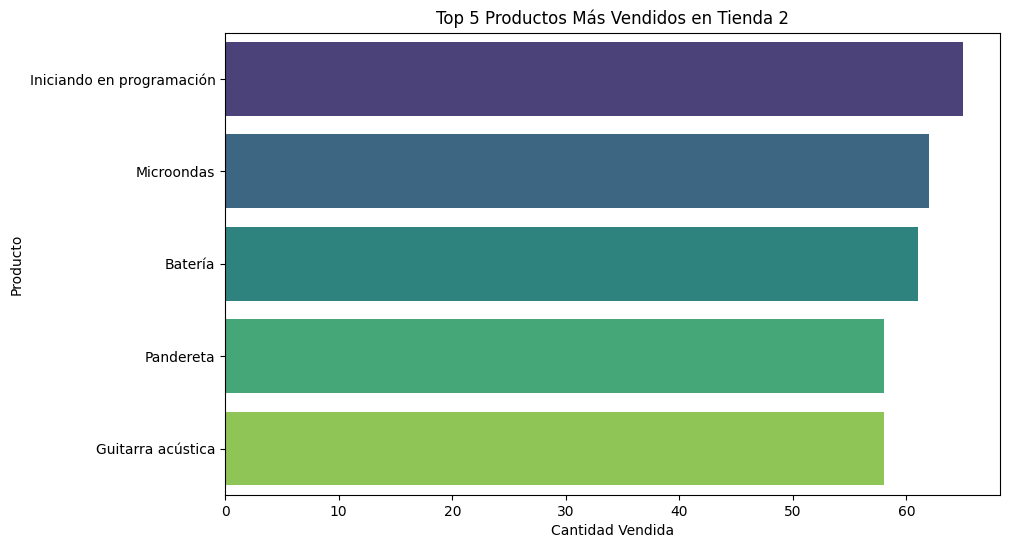

/tmp/ipykernel_569/1573215612.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_menos_vendidos, palette='magma')


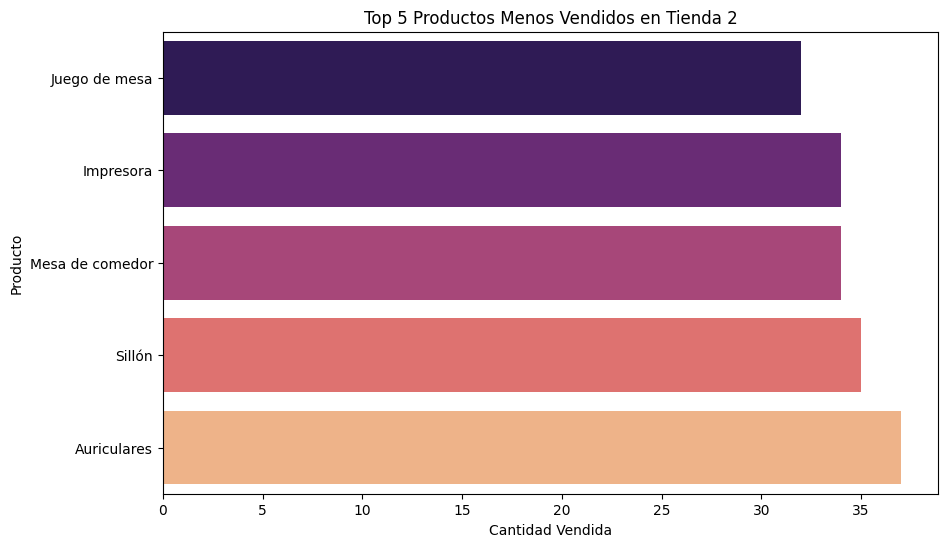



--- Tienda 3 ---

Top 5 Productos Más Vendidos:


,Tienda,Producto,Cantidad Vendida
129,Tienda 3,Kit de bancas,57
133,Tienda 3,Mesa de comedor,56
113,Tienda 3,Cama king,56
143,Tienda 3,Set de ollas,55
134,Tienda 3,Mesa de noche,55



Top 5 Productos Menos Vendidos:


,Tienda,Producto,Cantidad Vendida
111,Tienda 3,Bloques de construcción,35
144,Tienda 3,Set de vasos,36
136,Tienda 3,Mochila,36
135,Tienda 3,Microondas,36
152,Tienda 3,Vaso térmico,38


/tmp/ipykernel_569/1573215612.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_mas_vendidos, palette='viridis')


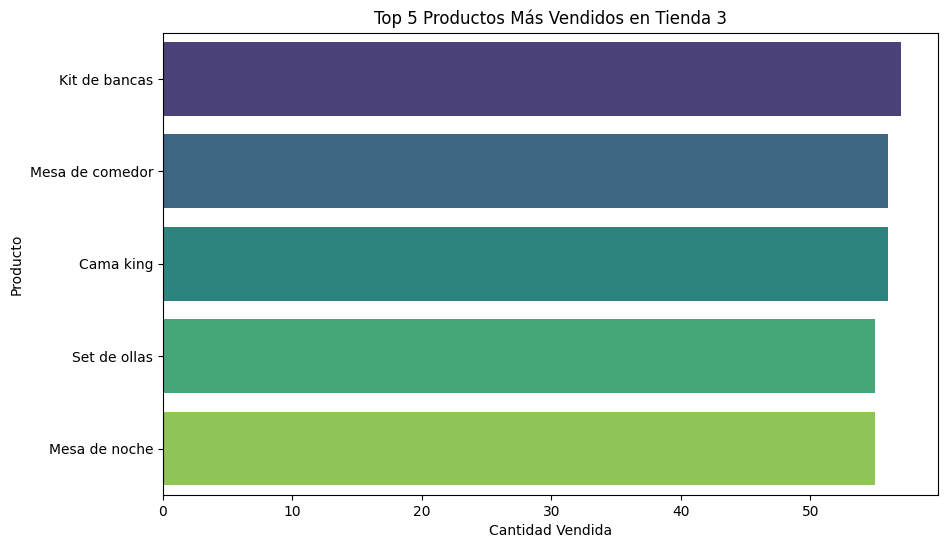

/tmp/ipykernel_569/1573215612.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_menos_vendidos, palette='magma')


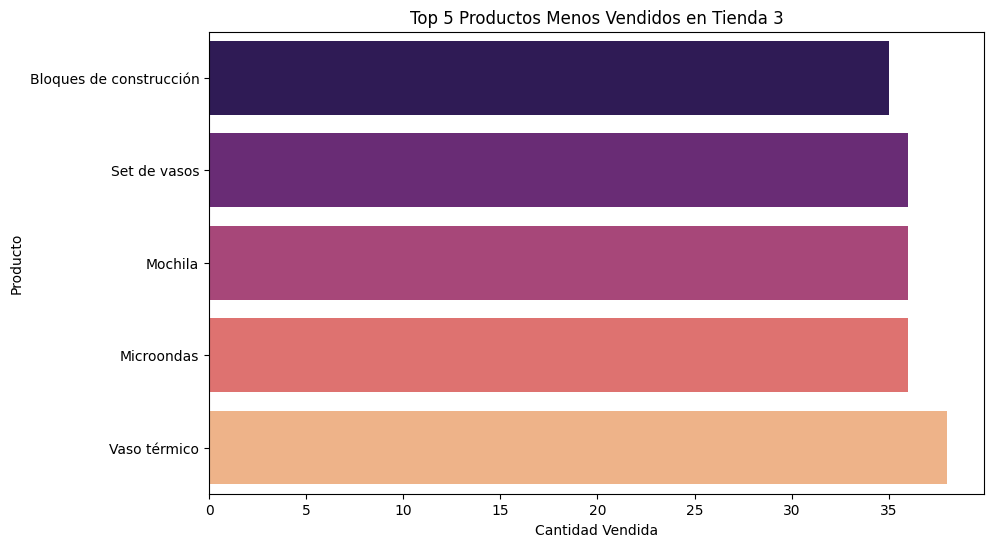



--- Tienda 4 ---

Top 5 Productos Más Vendidos:


,Tienda,Producto,Cantidad Vendida
163,Tienda 4,Cama box,62
168,Tienda 4,Cubertería,59
164,Tienda 4,Cama king,56
171,Tienda 4,Dashboards con Power BI,56
165,Tienda 4,Carrito de control remoto,55



Top 5 Productos Menos Vendidos:


,Tienda,Producto,Cantidad Vendida
175,Tienda 4,Guitarra eléctrica,33
154,Tienda 4,Armario,34
174,Tienda 4,Guitarra acústica,37
167,Tienda 4,Ciencia de datos con Python,38
181,Tienda 4,Lavadora de ropa,38


/tmp/ipykernel_569/1573215612.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_mas_vendidos, palette='viridis')


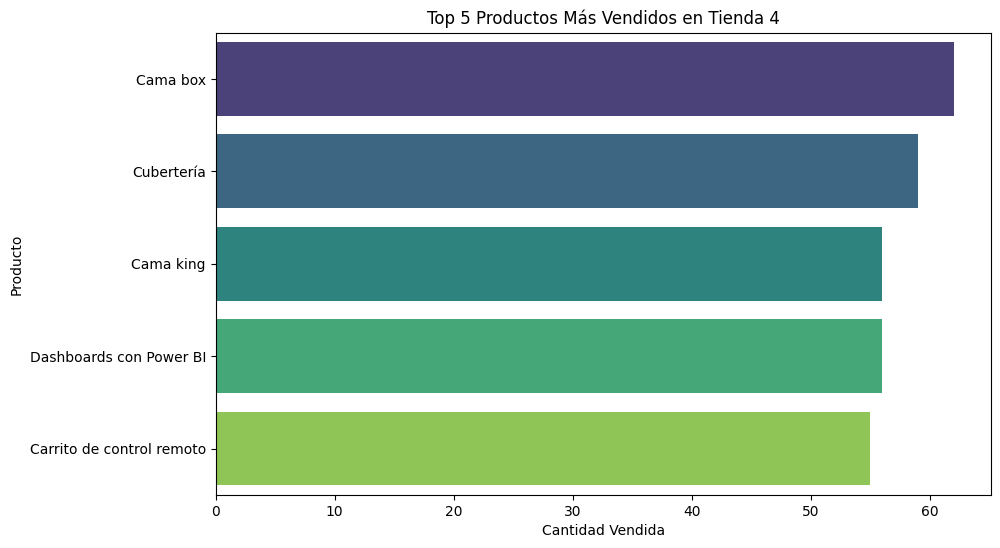

/tmp/ipykernel_569/1573215612.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_menos_vendidos, palette='magma')


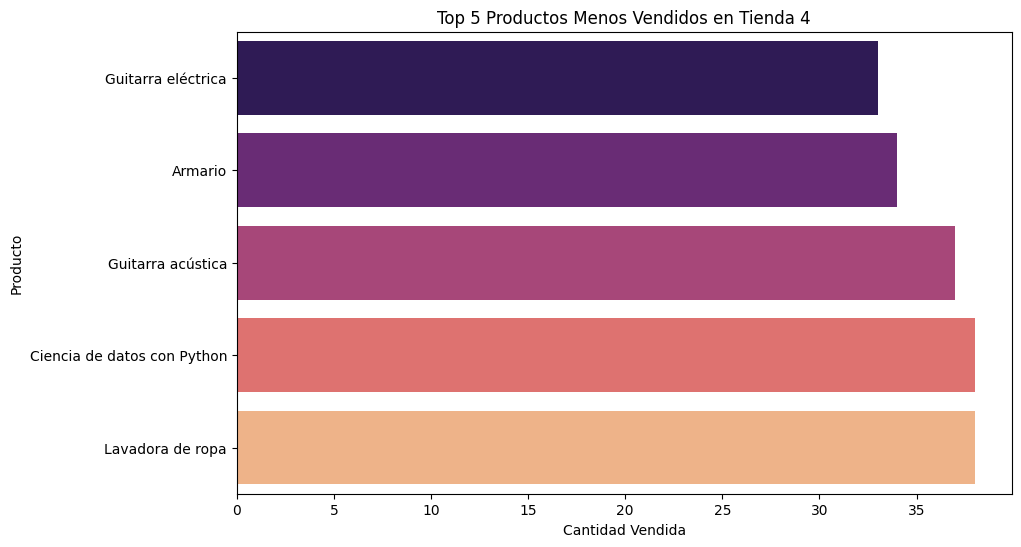

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la cantidad de cada producto vendido por tienda
ventas_por_producto_tienda = todas_las_tiendas_con_tienda.groupby(['Tienda', 'Producto']).size().reset_index(name='Cantidad Vendida')

print("--- Productos más y menos vendidos por tienda ---\n")

for tienda_name in todas_las_tiendas_con_tienda['Tienda'].unique():
    print(f"--- {tienda_name} ---")

    # Filtrar datos para la tienda actual
    df_tienda = ventas_por_producto_tienda[ventas_por_producto_tienda['Tienda'] == tienda_name]

    # Productos más vendidos (Top 5)
    productos_mas_vendidos = df_tienda.sort_values(by='Cantidad Vendida', ascending=False).head(5)
    print("\nTop 5 Productos Más Vendidos:")
    display(productos_mas_vendidos)

    # Productos menos vendidos (Bottom 5)
    productos_menos_vendidos = df_tienda.sort_values(by='Cantidad Vendida', ascending=True).head(5)
    print("\nTop 5 Productos Menos Vendidos:")
    display(productos_menos_vendidos)

    # Visualización para los productos más vendidos
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_mas_vendidos, palette='viridis')
    plt.title(f'Top 5 Productos Más Vendidos en {tienda_name}')
    plt.xlabel('Cantidad Vendida')
    plt.ylabel('Producto')
    plt.show()

    # Visualización para los productos menos vendidos
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Cantidad Vendida', y='Producto', data=productos_menos_vendidos, palette='magma')
    plt.title(f'Top 5 Productos Menos Vendidos en {tienda_name}')
    plt.xlabel('Cantidad Vendida')
    plt.ylabel('Producto')
    plt.show()

    print("\n" + "="*50 + "\n")

# 5. Envío promedio por tienda

# 5. Envío promedio por tienda

In [8]:
# Calcular el costo de envío promedio por tienda
costo_envio_promedio_por_tienda = todas_las_tiendas_con_tienda.groupby('Tienda')['Costo de envío'].mean().reset_index()

print("Costo de envío promedio de clientes por tienda:\n")
display(costo_envio_promedio_por_tienda.sort_values(by='Costo de envío', ascending=False))

Costo de envío promedio de clientes por tienda:



,Tienda,Costo de envío
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


# 6. Ingresos Totales por Tienda

In [9]:
# Calcular los ingresos totales por tienda
ingresos_por_tienda = todas_las_tiendas_con_tienda.groupby('Tienda')['Precio'].sum().reset_index()
ingresos_por_tienda.columns = ['Tienda', 'Ingresos Totales']

print("Ingresos totales por tienda:\n")
display(ingresos_por_tienda.sort_values(by='Ingresos Totales', ascending=False))

Ingresos totales por tienda:



,Tienda,Ingresos Totales
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


Tienda con Mayor Lucro (Ingresos Totales):
Basándonos estrictamente en los Ingresos Totales, la Tienda 1 es la que genera más dinero:

Tienda 1: $1,150,880,000

**Tienda 2:** $1,116,344,000

Tienda 3: $1,098,020,000

**Tienda 4:** $1,038,376,000

Por lo tanto, la Tienda 1 es la que actualmente aporta la mayor facturación bruta al negocio.

Tienda a Considerar para Eliminar:
Para decidir qué tienda eliminar, no solo debemos considerar los ingresos, sino también otros factores como la satisfacción del cliente y los costos operativos (como el envío):

Ingresos Totales: La Tienda 4 tiene los ingresos más bajos ($1,038,376,000), siendo la de menor rendimiento en ventas.

* **Calificación Promedio de Clientes:** La **Tienda 1** tiene la calificación promedio más baja (3.98), lo que podría indicar una menor satisfacción general del cliente, a pesar de sus altos ingresos.
* **Costo de Envío Promedio:** La **Tienda 1** tiene el costo de envío promedio más alto ($$1,038,376,000), siendo la de menor rendimiento en ventas.
* **Calificación Promedio de Clientes:** La **Tienda 1** tiene la calificación promedio más baja (3.98), lo que podría indicar una menor satisfacción general del cliente, a pesar de sus altos ingresos.
* **Costo de Envío Promedio:** La **Tienda 1** tiene el costo de envío promedio más alto ($26,018.61), lo que podría afectar su rentabilidad neta si los márgenes son ajustados. La Tienda 4 tiene el costo de envío promedio más bajo ($23,459.46).

Recomendación:

Si el objetivo principal es reducir las operaciones menos rentables en términos de volumen de ventas, la Tienda 4 sería la primera candidata a considerar para eliminación, ya que consistentemente tiene los ingresos más bajos.

Sin embargo, si la satisfacción del cliente y los costos operativos son una preocupación creciente, la Tienda 1, a pesar de sus altos ingresos, debería ser analizada más a fondo debido a su baja calificación promedio y sus altos costos de envío. Esto podría indicar problemas subyacentes que, a largo plazo, podrían erosionar su rentabilidad.

Para una decisión final sobre la eliminación de una tienda, sería crucial realizar un análisis de costos más detallado de cada sucursal (además de los costos de envío) para obtener el 'lucro' real y no solo los ingresos brutos.